# Modeling a Noisy Function using GP Models

This section provides implementation for Gaussian process based models for data with observation noise. The first block of code imports the required packages and methods.


In [11]:
import numpy as np
import torch
from scimlstudio.models import SingleOutputGP
from scimlstudio.utils import Standardize, Normalize
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.kernels import MaternKernel
from gpytorch.mlls import ExactMarginalLogLikelihood
import matplotlib.pyplot as plt
from scimlstudio.utils.evaluation_metrics import evaluate_scalar # importing to calculate nrmse metric

# Defining the device and data types
tkwargs = {"device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'), "dtype": torch.float64}

Often times, the data that is collected to model a function may be noisy. This noise could be due to the data being collected from an experiment and there is some randomness in the outcome of the experiment. In the code block below, the noisy version of the Forrester function is defined. This function is the Forrester function plus a simulated standard Gaussian noise term that is added to the function values. In this case, the function can be written as

$$f(\textbf{x})=(6x-2)^2 \sin(12x-4)+\epsilon$$
$$\epsilon \sim \mathcal{N}(0,1)$$

The block of code below defines the Forrester function with and without noise. 

In [12]:
noisy_forrester = lambda x: (6*x-2)**2*torch.sin(12*x-4) + torch.randn_like(x, **tkwargs)
forrester = lambda x: (6*x-2)**2*torch.sin(12*x-4)

Below block of code creates training dataset consists of 10 equally spaced points and creates a testing dataset of 100 equally spaced points.

In [13]:
# Training data with observation noise
xtrain = torch.linspace(0, 1, 10, **tkwargs)
ytrain = noisy_forrester(xtrain)

# Testing data
xtest = torch.linspace(0, 1, 100, **tkwargs)
ytest = forrester(xtest) 
# Testing data is generated without noise as that is the underlying true function

The GP model is created using `scimlstudio` package. Similar to the previous section on GP models, the GP models are created using the `SingleOutputGP` class which implements a single output GP model. The general set up of the GP model used in this section is the same as the GP model created for data without noise. The following changes from the implementation in the last section were made in this section:
- The `noiseless` argument of the `SingleOutputGP` must be set to `False`. This will allow the GP model to account for the observation noise in the data. This is required to correctly capture the observation noise within the data. 
- The `likelihood_module` argument of the `SingleOutputGP` is set to `GaussianLikelihood()` from `gpytorch`. This will use the Gaussian likelihood with observation noise from `gpytorch` without any log normal priors. This is not required for capturing observation noise, but it is shown here to demonstrate that a custom likelihood can also be used with the `SingleOutputGP` class. 


The code block below demonstrates an example of this implementation. The GP model is trained using the radial basis function (squared exponential) kernel. 

Optimal lengthscale value: 0.18652808666229248


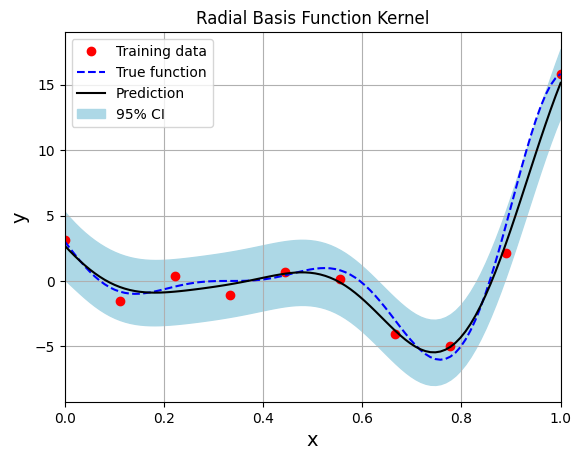

In [14]:
# Create model
gp = SingleOutputGP(x_train=xtrain.reshape(-1,1), y_train=ytrain.reshape(-1,1), output_transform=Standardize, input_transform=Normalize, noiseless=False, 
                    likelihood_module=GaussianLikelihood())

# Defining a few things to train the model
mll = ExactMarginalLogLikelihood(gp.likelihood, gp) # loss function 
optimizer = torch.optim.Adam(gp.parameters(), lr=0.01) # optimizer

# Training the model
gp.fit(training_iterations=1000, mll=mll, optimizer=optimizer)

print(f"Optimal lengthscale value: {gp.covar_module.base_kernel.lengthscale.item()}")

# Prediction for plotting
ytest_pred, ytest_std = gp.predict(xtest.reshape(-1,1))

# Plotting
fig, ax = plt.subplots()
ax.plot(xtrain.numpy(force=True), ytrain.numpy(force=True), 'ro', label='Training data')
ax.plot(xtest.numpy(force=True), ytest.numpy(force=True), 'b--', label='True function')
ax.plot(xtest.numpy(force=True), ytest_pred.numpy(force=True), 'k', label='Prediction')
ax.fill_between(xtest.numpy(force=True), ytest_pred.reshape(-1,).numpy(force=True) - 2*torch.sqrt(ytest_std.reshape(-1,)).numpy(force=True), 
                ytest_pred.reshape(-1,).numpy(force=True) + 2*torch.sqrt(ytest_std.reshape(-1,)).numpy(force=True), color='lightblue', label='95% CI')
ax.set_xlim([0, 1])
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.title("Radial Basis Function Kernel")
ax.legend()
ax.grid()

Few important points to note:
- When there is observation noise, the GP model does not fully interpolate the training data of the model. 
- There is finite variance at the training sample points which not close to zero due to the consideration of noise within the GP model.

The block of code below fits the GP model with Matern kernel on different sample sizes, prints the optimal lengthscale of the model and plots the fit of the model on the data with observation noise. The setup of the GP model is the same as described previously. 

Optimal lengthscale value for 5 samples: 0.18836261332035065
Optimal lengthscale value for 15 samples: 0.17730486392974854
Optimal lengthscale value for 20 samples: 0.22004681825637817
Optimal lengthscale value for 25 samples: 0.1805996149778366
Optimal lengthscale value for 30 samples: 0.1854223906993866
Optimal lengthscale value for 35 samples: 0.29783865809440613
Optimal lengthscale value for 40 samples: 0.24211272597312927


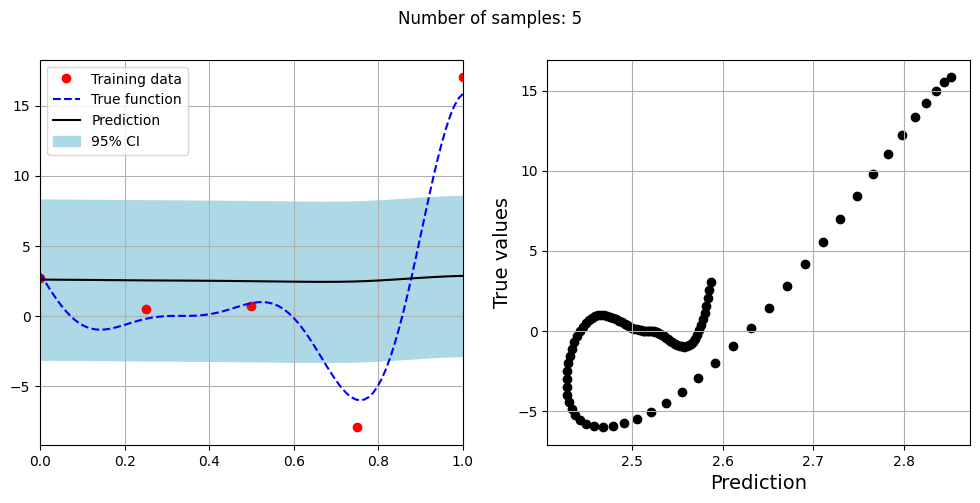

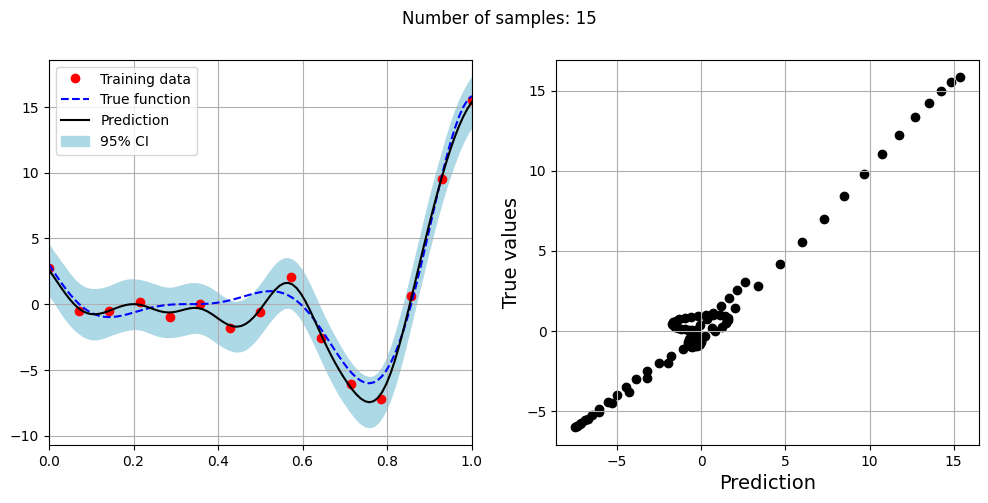

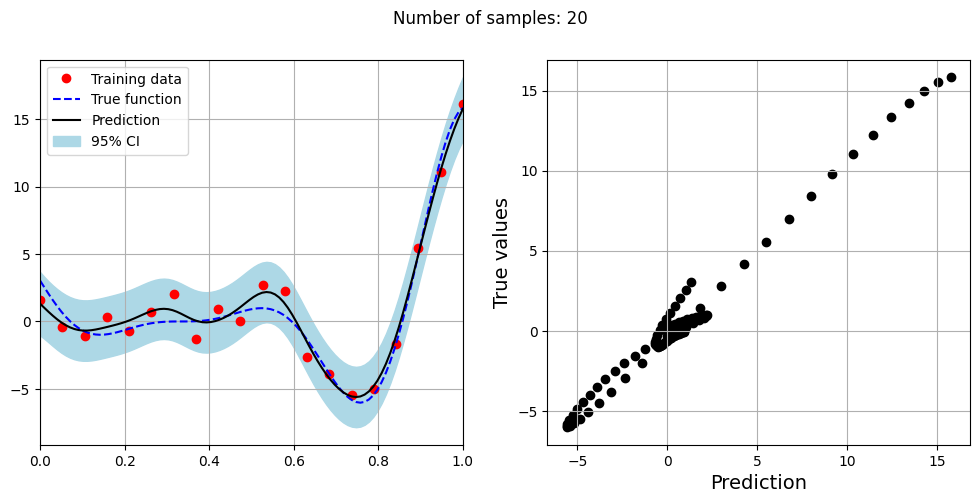

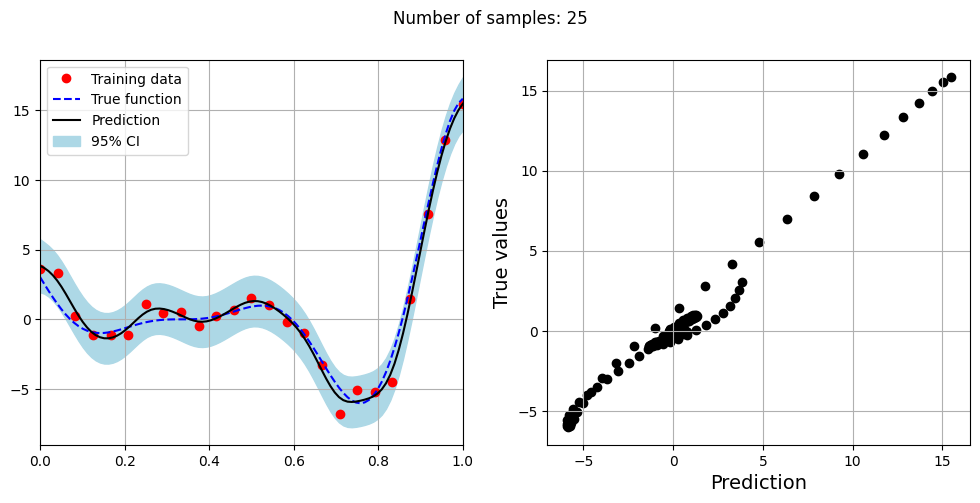

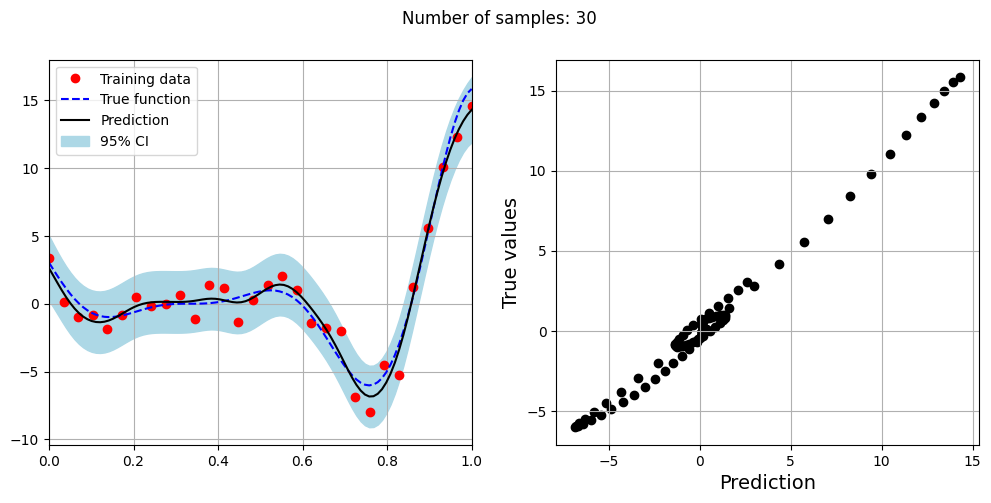

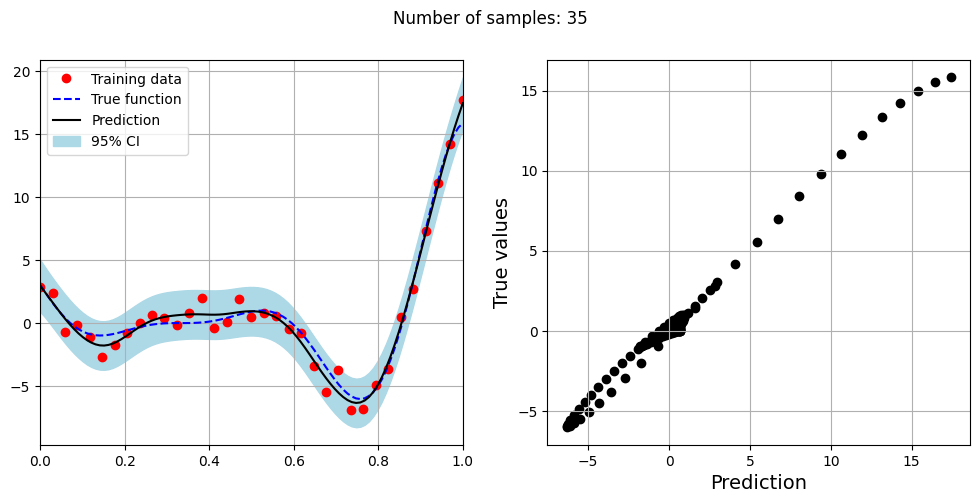

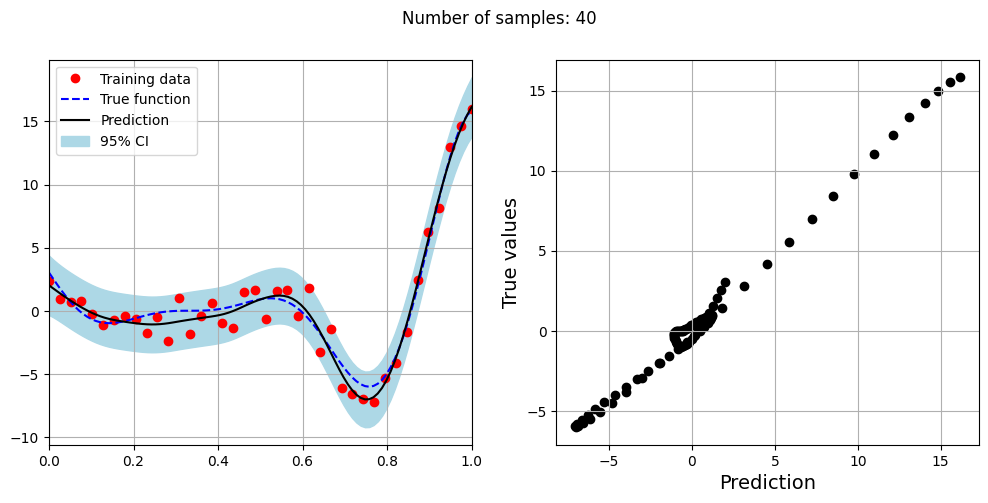

In [15]:
# Creating array of training sample sizes
samples = [5,15,20,25,30,35,40]

# Fitting with different sample size
for sample in samples:
    
    xtrain = torch.linspace(0, 1, sample, **tkwargs)
    ytrain = noisy_forrester(xtrain)
    
    # Create model
    gp = SingleOutputGP(x_train=xtrain.reshape(-1,1), y_train=ytrain.reshape(-1,1), output_transform=Standardize, input_transform=Normalize, covar_module=MaternKernel,
                        likelihood_module=GaussianLikelihood(), noiseless=False)

    # Defining a few things to train the model
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp) # loss function 
    optimizer = torch.optim.Adam(gp.parameters(), lr=0.01) # optimizer

    # Training the model
    gp.fit(training_iterations=1000, mll=mll, optimizer=optimizer)

    print(f"Optimal lengthscale value for {sample} samples: {gp.covar_module.base_kernel.lengthscale.item()}")

    # Prediction for plotting
    ytest_pred, ytest_std = gp.predict(xtest.reshape(-1,1))

    # Plotting prediction
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    
    ax[0].plot(xtrain.numpy(force=True), ytrain.numpy(force=True), 'ro', label='Training data')
    ax[0].plot(xtest.numpy(force=True), ytest.numpy(force=True), 'b--', label='True function')
    ax[0].plot(xtest.numpy(force=True), ytest_pred.numpy(force=True), 'k', label='Prediction')
    ax[0].fill_between(xtest.numpy(force=True), ytest_pred.reshape(-1,).numpy(force=True) - 2*torch.sqrt(ytest_std.reshape(-1,)).numpy(force=True), 
                ytest_pred.reshape(-1,).numpy(force=True) + 2*torch.sqrt(ytest_std.reshape(-1,)).numpy(force=True), color='lightblue', label='95% CI')
    ax[0].set_xlim([0, 1])
    plt.xlabel("x", fontsize=14)
    plt.ylabel("y", fontsize=14)
    ax[0].legend(loc="upper left")
    ax[0].grid()
    
    ax[1].scatter(ytest_pred, ytest, c="k")
    ax[1].set_xlabel("Prediction", fontsize=14)
    ax[1].set_ylabel("True values", fontsize=14)
    ax[1].grid()
    
    fig.suptitle("Number of samples: {}".format(sample))